
# Q5 Results Analysis

This section analyzes the results produced in **Q5 – Temporal Performance Analysis**.

Unlike previous experiments that used random train/test splits, Q5 evaluates model performance across chronological time segments.

The objective is to determine:

1. Whether fraud-detection performance changes over time.
2. Whether concept drift exists in the dataset.
3. Which temporal periods are more difficult for fraud detection.
4. Whether feature importance remains stable across time.

---

The analysis focuses on:

- Recall
- Precision
- F1 Score
- PR-AUC
- ROC-AUC
- False Negatives
- Feature Drift



## Load Experiment Results

Load temporal performance results and feature drift analysis generated during Q5.


In [1]:

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [2]:
current_path = Path.cwd()

while current_path.name != "MachineLearningProject":
    current_path = current_path.parent

PROJECT_ROOT = current_path


In [3]:
q5_results = pd.read_csv(
    PROJECT_ROOT / "out" / "Q5_results.csv"
)

q5_drift = pd.read_csv(
    PROJECT_ROOT / "out" / "Q5_feature_drift.csv"
)

print(f"Results rows: {len(q5_results)}")
print(f"Drift rows: {len(q5_drift)}")

q5_results.head()


Results rows: 5
Drift rows: 30


,split,train_samples,test_samples,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,1,47467,47467,0.999537,0.945455,0.732394,0.825397,0.923167,0.809166,47393,3,19,52
1,2,94934,47467,0.999621,0.869565,0.769231,0.816327,0.929415,0.704896,47409,6,12,40
2,3,142401,47467,0.999094,0.845238,0.702970,0.767568,0.977737,0.762233,47353,13,30,71
3,4,189868,47467,0.999579,0.886792,0.770492,0.824561,0.967292,0.794313,47400,6,14,47
4,5,237335,47472,0.999558,0.884615,0.754098,0.814159,0.950070,0.790241,47405,6,15,46



## Dataset Overview

Inspect the temporal experiment structure before continuing.

Each row corresponds to one forward temporal split.


In [4]:

q5_results.info()

q5_results.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   split            5 non-null      int64  
 1   train_samples    5 non-null      int64  
 2   test_samples     5 non-null      int64  
 3   accuracy         5 non-null      float64
 4   precision        5 non-null      float64
 5   recall           5 non-null      float64
 6   f1               5 non-null      float64
 7   roc_auc          5 non-null      float64
 8   pr_auc           5 non-null      float64
 9   true_negatives   5 non-null      int64  
 10  false_positives  5 non-null      int64  
 11  false_negatives  5 non-null      int64  
 12  true_positives   5 non-null      int64  
dtypes: float64(6), int64(7)
memory usage: 648.0 bytes


,split,train_samples,test_samples,accuracy,precision,recall,f1,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000
mean,3.000000,142401.000000,47468.000000,0.999478,0.886333,0.745837,0.809602,0.949536,0.772170,47392.000000,6.800000,18.00000,51.200000
std,1.581139,75051.916848,2.236068,0.000217,0.036975,0.028468,0.024011,0.023511,0.041262,22.605309,3.701351,7.17635,11.861703
min,1.000000,47467.000000,47467.000000,0.999094,0.845238,0.702970,0.767568,0.923167,0.704896,47353.000000,3.000000,12.00000,40.000000
25%,2.000000,94934.000000,47467.000000,0.999537,0.869565,0.732394,0.814159,0.929415,0.762233,47393.000000,6.000000,14.00000,46.000000
50%,3.000000,142401.000000,47467.000000,0.999558,0.884615,0.754098,0.816327,0.950070,0.790241,47400.000000,6.000000,15.00000,47.000000
75%,4.000000,189868.000000,47467.000000,0.999579,0.886792,0.769231,0.824561,0.967292,0.794313,47405.000000,6.000000,19.00000,52.000000
max,5.000000,237335.000000,47472.000000,0.999621,0.945455,0.770492,0.825397,0.977737,0.809166,47409.000000,13.000000,30.00000,71.000000



# Temporal Recall Analysis

Recall is the most important metric in fraud detection because false negatives correspond to missed fraud transactions.

If recall decreases in later temporal segments, this may indicate concept drift.


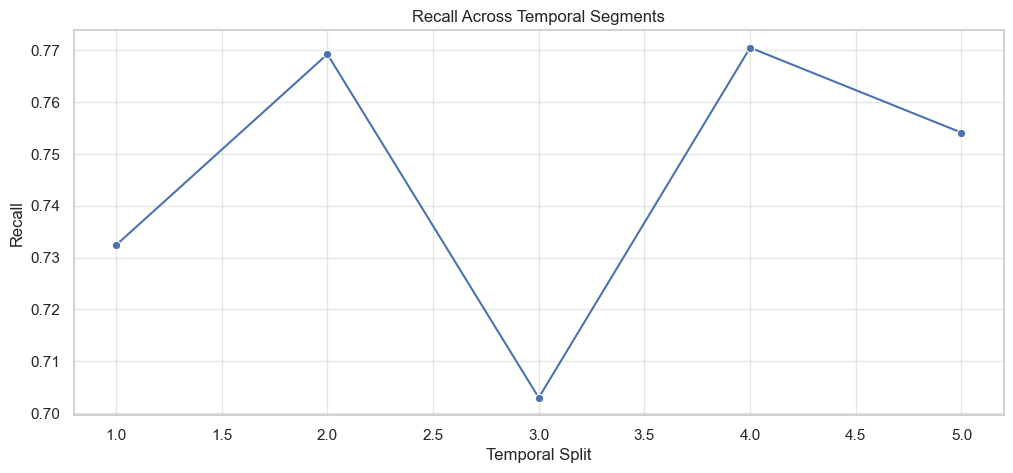

In [5]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q5_results,
    x="split",
    y="recall",
    marker="o"
)

plt.title("Recall Across Temporal Segments")
plt.xlabel("Temporal Split")
plt.ylabel("Recall")

plt.show()



### Discussion

Observe whether recall remains stable or gradually decreases as testing data moves further into the future.

A clear downward trend may suggest evolving fraud patterns.



## Precision Across Time

Precision measures the fraction of detected fraud cases that are truly fraudulent.

Temporal variation in precision may indicate changes in transaction behavior.


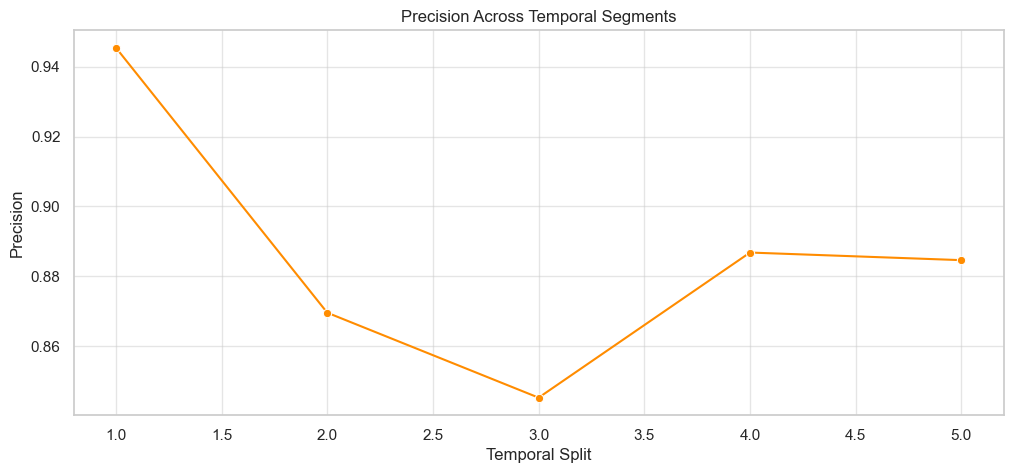

In [6]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q5_results,
    x="split",
    y="precision",
    marker="o",
    color="darkorange"
)

plt.title("Precision Across Temporal Segments")
plt.xlabel("Temporal Split")
plt.ylabel("Precision")

plt.show()



## F1 Score Across Time

F1-score combines precision and recall into a single metric.

This provides an overall measure of fraud-detection quality.


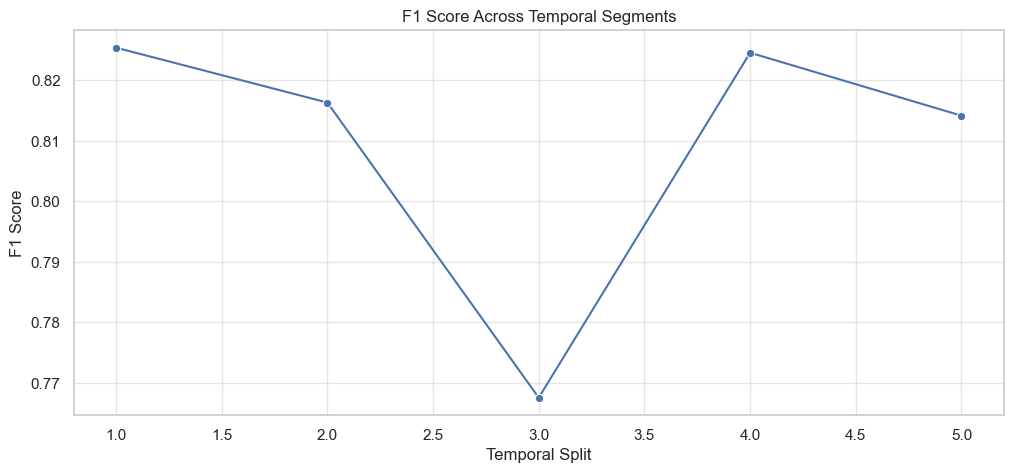

In [7]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q5_results,
    x="split",
    y="f1",
    marker="o"
)

plt.title("F1 Score Across Temporal Segments")
plt.xlabel("Temporal Split")
plt.ylabel("F1 Score")

plt.show()



## ROC-AUC Across Temporal Segments

ROC-AUC measures ranking ability independently of decision threshold.

Stable ROC-AUC indicates the model still separates fraud from non-fraud effectively.


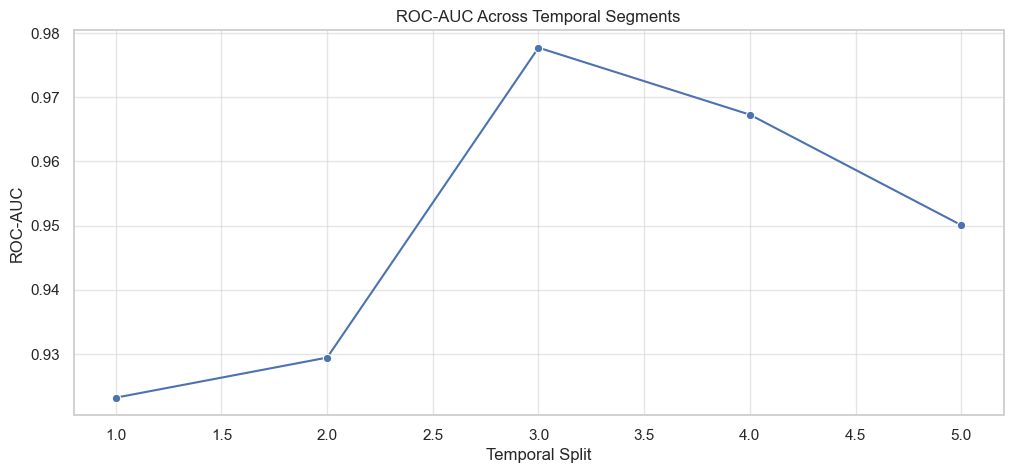

In [8]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q5_results,
    x="split",
    y="roc_auc",
    marker="o"
)

plt.title("ROC-AUC Across Temporal Segments")
plt.xlabel("Temporal Split")
plt.ylabel("ROC-AUC")

plt.show()



## PR-AUC Across Temporal Segments

PR-AUC is especially important for imbalanced fraud-detection datasets.

It reflects minority-class performance more reliably than accuracy.


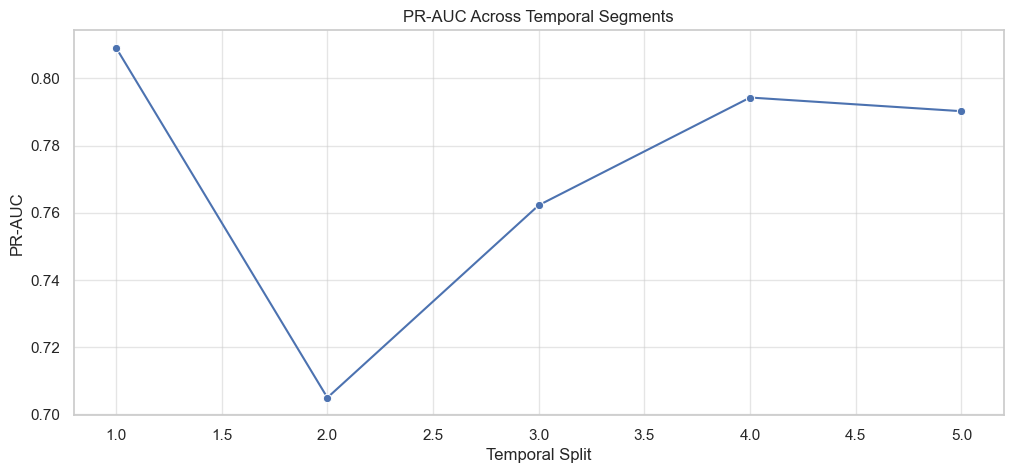

In [9]:

plt.figure(figsize=(12,5))

sns.lineplot(
    data=q5_results,
    x="split",
    y="pr_auc",
    marker="o"
)

plt.title("PR-AUC Across Temporal Segments")
plt.xlabel("Temporal Split")
plt.ylabel("PR-AUC")

plt.show()



# Missed Fraud Cases

False negatives represent fraud transactions that the model failed to detect.

An increasing number of false negatives over time is a strong indicator of concept drift.


/tmp/ipykernel_6444/1914220580.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


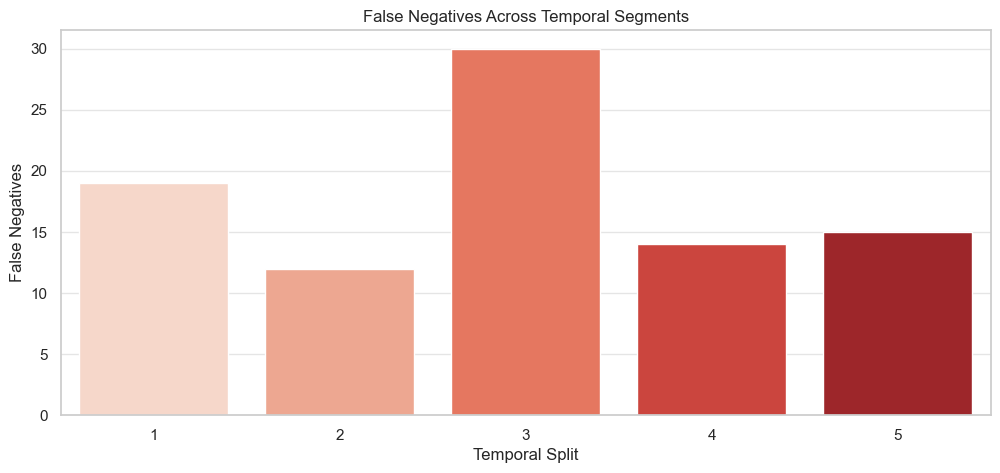

In [10]:

plt.figure(figsize=(12,5))

sns.barplot(
    data=q5_results,
    x="split",
    y="false_negatives",
    palette="Reds"
)

plt.title("False Negatives Across Temporal Segments")
plt.xlabel("Temporal Split")
plt.ylabel("False Negatives")

plt.show()



## Combined Performance Overview

Compare the main metrics simultaneously to identify performance degradation patterns.


In [11]:

metrics = [
    "precision",
    "recall",
    "f1",
    "pr_auc"
]

multi_df = q5_results[
    ["split"] + metrics
].melt(
    id_vars="split",
    var_name="metric",
    value_name="value"
)



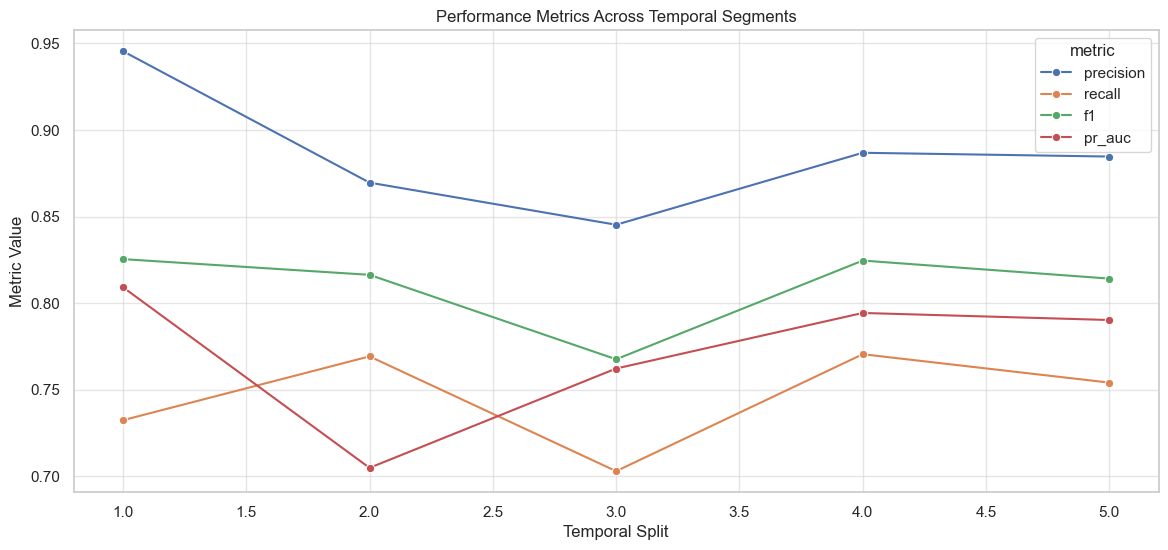

In [12]:

plt.figure(figsize=(14,6))

sns.lineplot(
    data=multi_df,
    x="split",
    y="value",
    hue="metric",
    marker="o"
)

plt.title(
    "Performance Metrics Across Temporal Segments"
)

plt.xlabel("Temporal Split")
plt.ylabel("Metric Value")

plt.show()



# Feature Importance Drift

This section investigates whether the model relies on the same features throughout time.

Large drift values imply fraud patterns evolve across temporal segments.


In [13]:

q5_drift.sort_values(
    "drift_score",
    ascending=False
).head(10)


,feature,mean_importance,std_importance,drift_score
3,V3,0.095107,0.032186,0.023708
0,V14,0.209694,0.010084,0.010417
5,V4,0.089611,0.008957,0.009165
2,V12,0.105246,0.009695,0.009085
7,V16,0.045853,0.006757,0.007948
13,V6,0.008880,0.009205,0.007244
6,V11,0.049584,0.006390,0.007222
4,V17,0.091485,0.008553,0.007089
9,V9,0.023502,0.004600,0.007062
8,V2,0.045199,0.009065,0.006723



## Most Dynamic Features

These features change importance the most across time.


In [14]:

top_drift = (
    q5_drift
    .sort_values(
        "drift_score",
        ascending=False
    )
    .head(10)
)


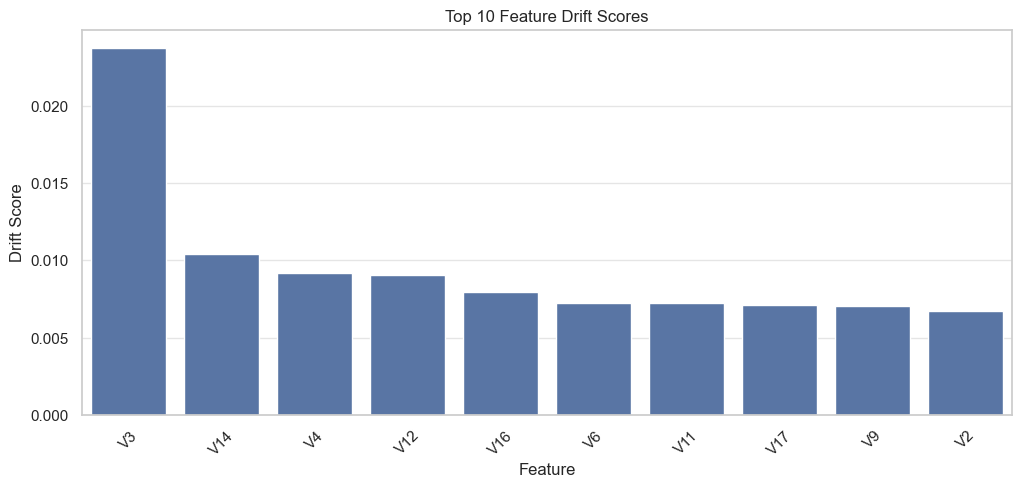

In [15]:

plt.figure(figsize=(12,5))

sns.barplot(
    data=top_drift,
    x="feature",
    y="drift_score"
)

plt.title(
    "Top 10 Feature Drift Scores"
)

plt.xlabel("Feature")
plt.ylabel("Drift Score")

plt.xticks(rotation=45)

plt.show()



## Most Stable Features

Stable features remain important regardless of temporal segment.


In [16]:

stable_features = (
    q5_drift
    .sort_values(
        "std_importance"
    )
    .head(10)
)


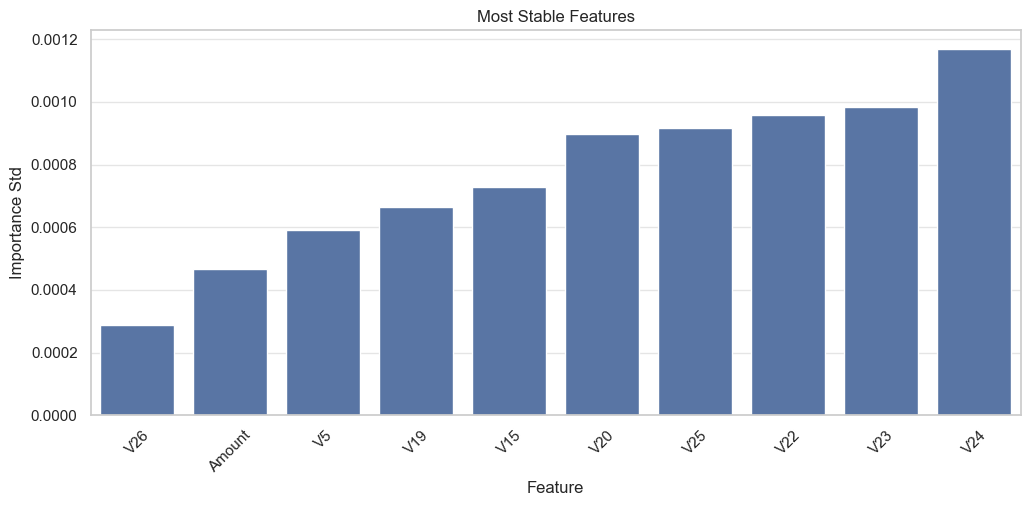

In [17]:

plt.figure(figsize=(12,5))

sns.barplot(
    data=stable_features,
    x="feature",
    y="std_importance"
)

plt.title(
    "Most Stable Features"
)

plt.xlabel("Feature")
plt.ylabel("Importance Std")

plt.xticks(rotation=45)

plt.show()



## Feature Drift Heatmap

Visual representation of average feature importance and drift.


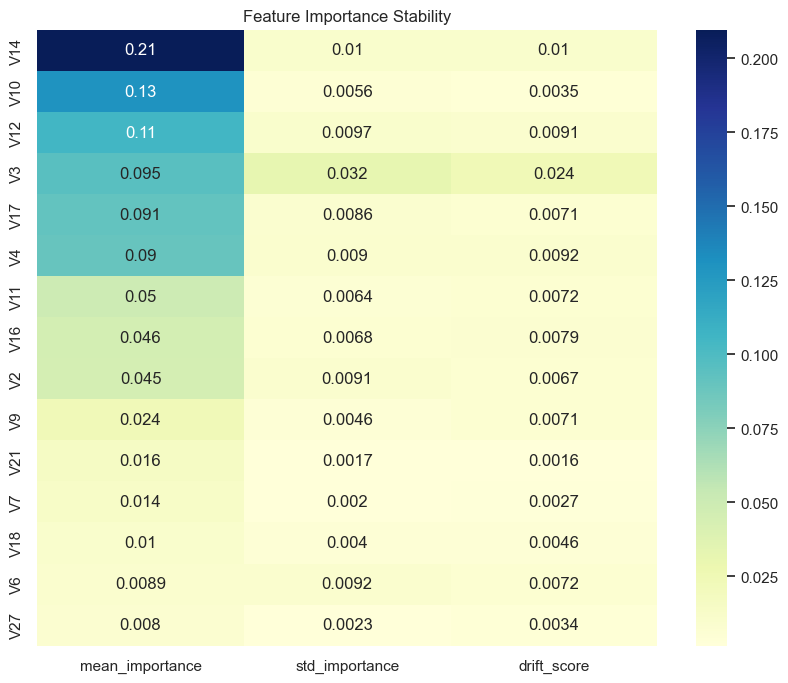

In [18]:

heatmap_df = (
    q5_drift
    .sort_values(
        "mean_importance",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_df[
        [
            "mean_importance",
            "std_importance",
            "drift_score"
        ]
    ],
    annot=True,
    cmap="YlGnBu",
    yticklabels=heatmap_df["feature"]
)

plt.title(
    "Feature Importance Stability"
)

plt.show()



# Q5 Conclusions

The temporal analysis demonstrates how fraud-detection performance evolves over time.

Key questions answered:

1. Does performance remain stable across temporal segments?
2. Is there evidence of concept drift?
3. Which time periods are most difficult for fraud detection?
4. Are feature-importance rankings stable?

---

### Indicators of Concept Drift

Concept drift is supported if:

- Recall decreases over time.
- PR-AUC decreases over time.
- False negatives increase.
- Feature drift scores are high.

---

### Indicators of Stability

Temporal stability is supported if:

- Recall remains consistent.
- PR-AUC remains consistent.
- False negatives stay low.
- Feature importance rankings remain stable.

---

The temporal experiment provides insight into whether periodic model retraining would be necessary in a real-world fraud-detection system.
